In [26]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Hp\AppData\Local\Temp\ipykernel_42992\4206787429.py:1: SyntaxWarning: invalid escape sequence '\p'
  frame = cv2.imread('data\players.png')


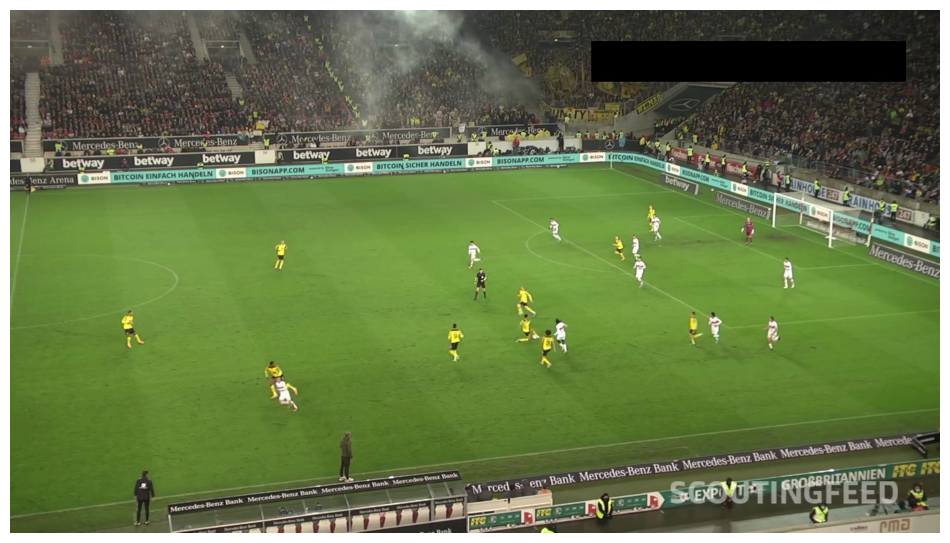

In [4]:
frame = cv2.imread('data\players.png')
frame  = cv2.cvtColor(frame , cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(frame)
plt.axis('off')
plt.show()


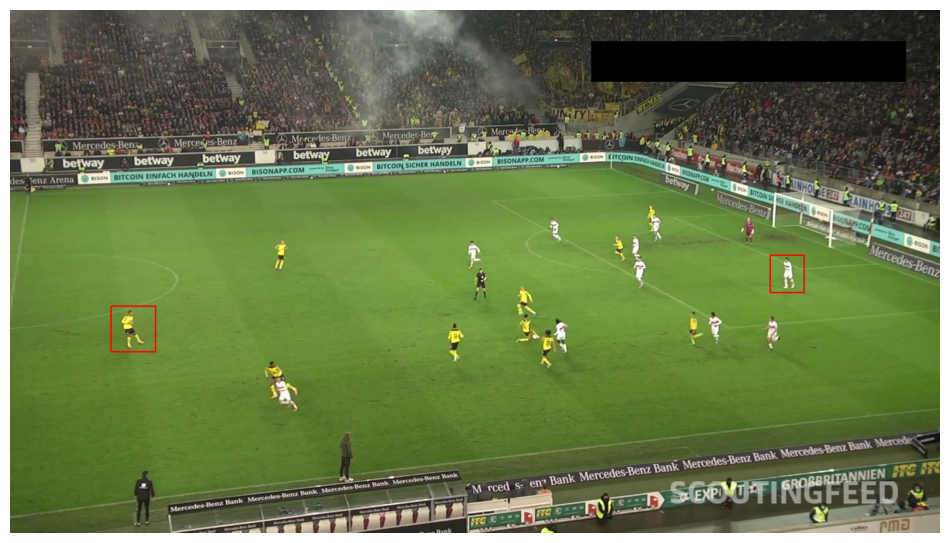

In [7]:
boxes = [
    [208, 612, 300, 706] ,
    [1569, 507, 1639, 584]
]

for x1, y1, x2, y2 in boxes:
    cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)



plt.figure(figsize=(12, 8))
plt.imshow(frame)
plt.axis('off')
plt.show()

In [ ]:
# crop box from image 
for i, box in enumerate(boxes):
    x1, y1, x2, y2 = box
    cropped_image = frame[y1:y2, x1:x2]

    cv2.imwrite(
        f'output/player_{i}.png',
        cv2.cvtColor(cropped_image, cv2.COLOR_RGB2BGR)
    )

In [ ]:
cropped_players = []

for box in boxes:
    x1, y1, x2, y2 = box
    cropped_player = frame[y1:y2, x1:x2]
    cropped_players.append(cropped_player)

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Hp\AppData\Local\Temp\ipykernel_42992\3157551587.py:1: SyntaxWarning: invalid escape sequence '\c'
  image_path = 'output\cropped_image.jpg'


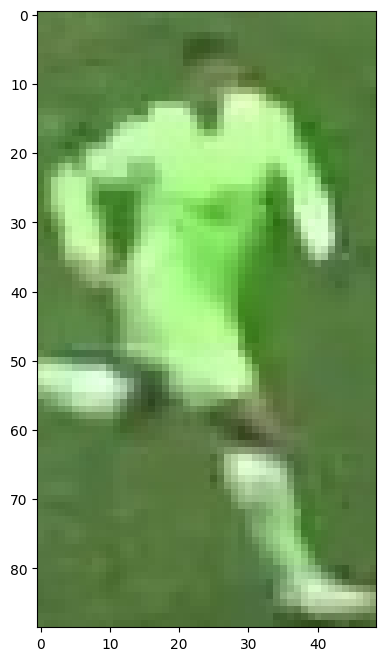

In [34]:
image_path = 'output\cropped_image.jpg'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


plt.figure(figsize=(12, 8))
plt.imshow(image)

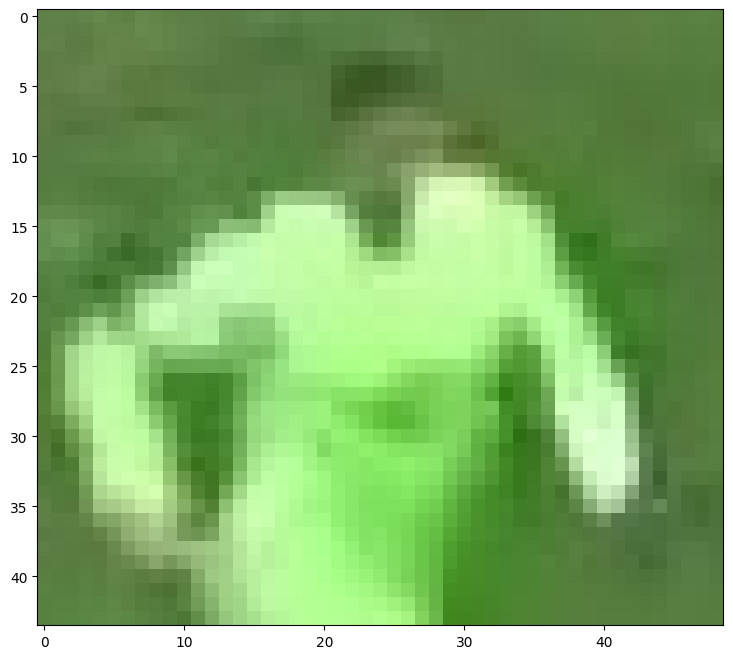

In [35]:
# take the upper half of the image
upper_body = image[:image.shape[0]//2, :]

plt.figure(figsize=(12, 8))
plt.imshow(upper_body)

## Cluster the image into 2 clusters

 - background color in cluster

 - teshirt color in another cluster and get the average color of the teshirt and use it to classify the player



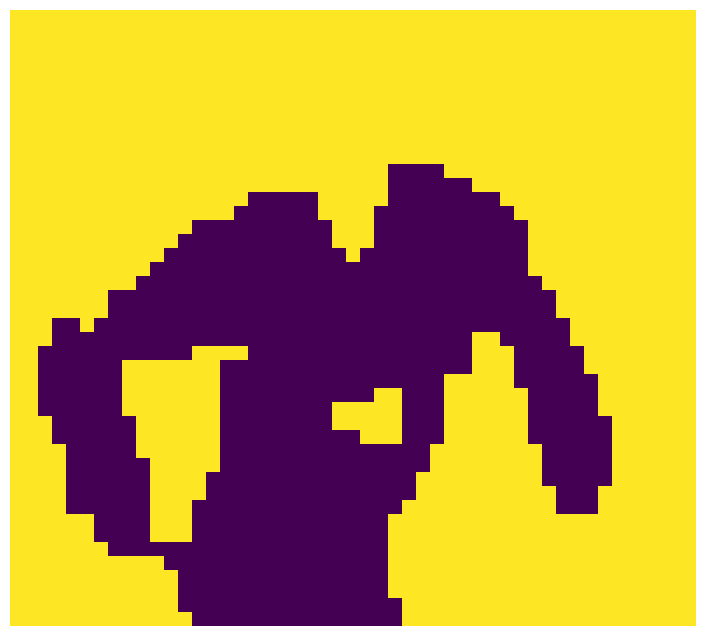

In [36]:
# reshape the image to a 2D array of pixels
image_2d = upper_body.reshape(-1, 3)

# perform k-means clustering to find 2 clusters (background and t-shirt)
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

# get the cluster labels 
labels = kmeans.labels_


# reshape the labels back to the original image shape
clustered_image = labels.reshape(upper_body.shape[0], upper_body.shape[1])

# Display the clustered image
plt.figure(figsize=(12, 8))
plt.imshow(clustered_image)
plt.axis('off')
plt.show()



In [37]:
corner_clusters = [clustered_image[0, 0], clustered_image[0, -1], clustered_image[-1, 0], clustered_image[-1, -1]]
non_player_cluster = 1 if corner_clusters.count(1) > corner_clusters.count(0) else 0
print(f"Non-player cluster: {non_player_cluster}")

Non-player cluster: 1


In [38]:
player_cluster = 1 - non_player_cluster
print(f"Player cluster: {player_cluster}")

Player cluster: 0


In [39]:
kmeans.cluster_centers_[player_cluster]


array([171.38378378, 235.65405405, 142.8472973 ])